BQ-PYTHON-SDK - WARNING - Beta version 0.8.3b1 of BlueQubit Python SDK is being used.
BQ-PYTHON-SDK - INFO - There is a newer version of BlueQubit Python SDK available on PyPI. We recommend upgrading. Run 'pip install --upgrade bluequbit' to upgrade from your version 0.8.3b1 to 0.12.0b1.
BQ-PYTHON-SDK - INFO - Submitted: Job ID: lOW2LpVOoijEeeBW, device: cpu, run status: COMPLETED, created on: 2025-04-13 01:45:10 UTC, cost: $0.00, run time: 7 ms, queue time: 99 ms, num qubits: 4


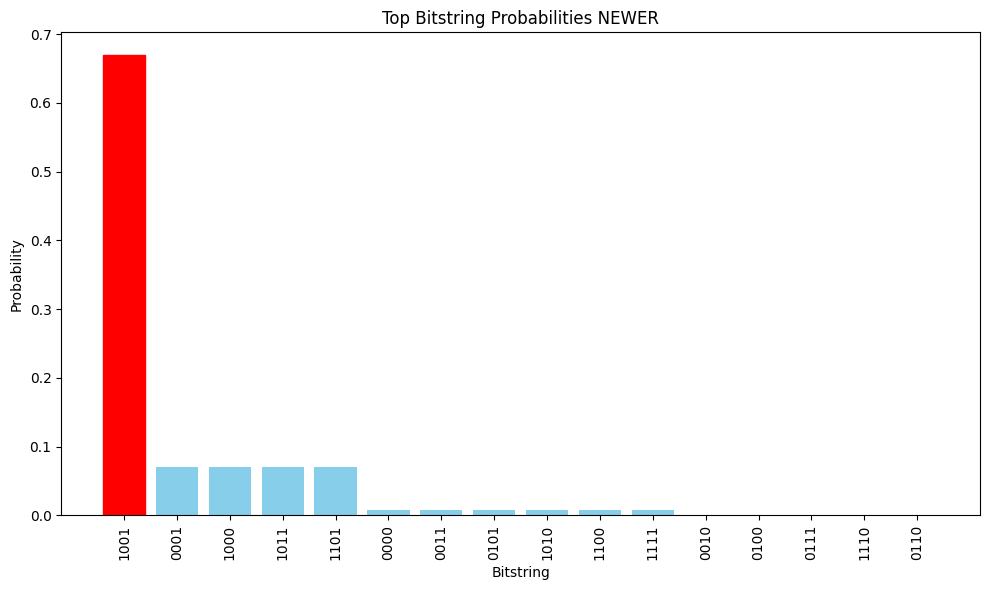

The peak bitstring for Problem 1 is: 1001


In [19]:
########## Quantum Circuit Solver - PROBLEM 1 Little Peak - BlueQubit Hackathon 2025 by Jamie Kraus 04/12/2025 ##########

import bluequbit
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def solve_problem_1(api_key, qasm_file_path, plot_results=True):
    """
    Solves Problem 1 of the BlueQubit Hackathon by finding the peak bitstring
    in a 4-qubit circuit, and optionally plots the results.

    Args:
        api_key (str): Your BlueQubit API key.
        qasm_file_path (str): The path to the .qasm file.
        plot_results (bool, optional): Whether to plot the bitstring probabilities.
            Defaults to True.

    Returns:
        str: The peak bitstring (or None on error).
    """
    try:
        # Initialize BlueQubit with the provided API key
        bq = bluequbit.init(api_key)

        # Load the circuit from the .qasm file
        with open(qasm_file_path, 'r') as f:
            qasm_content = f.read()

        # Create a QuantumCircuit object from the .qasm file content
        circuit = QuantumCircuit.from_qasm_str(qasm_content)

        # Simulate the circuit using BlueQubit (statevector simulation)
        result = bq.run(circuit)  # Removed backend argument
        statevector = Statevector.from_instruction(circuit) #changed how statevector is obtained

        # Get the probabilities for each bitstring
        probabilities = statevector.probabilities()

        # Get the binary strings
        num_qubits = circuit.num_qubits
        bitstrings = [format(i, '0' + str(num_qubits) + 'b') for i in range(2**num_qubits)]

        # Create a DataFrame for easy manipulation and visualization
        df = pd.DataFrame({'Bitstring': bitstrings, 'Probability': probabilities})

        # Sort the DataFrame by probability in descending order
        df = df.sort_values(by='Probability', ascending=False)

        # Find the bitstring with the maximum probability
        peak_bitstring = df.iloc[0]['Bitstring'] #gets the bitstring with the highest probability

        if plot_results:
            # Select the top N bitstrings for plotting
            N = min(20, len(df))  # Adjust this number based on how many bitstrings you want to visualize
            top_df = df.head(N)

            # Create the plot to visualize the bitstring probabilities
            plt.figure(figsize=(10, 6))
            bars = plt.bar(top_df['Bitstring'], top_df['Probability'], color='skyblue')
            plt.xticks(rotation=90)  # Rotate the bitstring labels on the x-axis for readability
            plt.xlabel('Bitstring')
            plt.ylabel('Probability')
            plt.title('Top Bitstring Probabilities NEWER')

            # Highlight the peak bitstring in red
            for bar, bitstring in zip(bars, top_df['Bitstring']):
                if bitstring == peak_bitstring:
                    bar.set_color('red')

            # Adjust layout for better fit and display the plot
            plt.tight_layout()
            plt.show()

        return peak_bitstring

    except Exception as e:
        print(f"An error occurred: {e}")
        return None

if __name__ == "__main__":
    # Replace with your actual API key and .qasm file path
    api_key = "YOUR_BLUEQUBIT_API_KEY"  # Replace with your BlueQubit API key
    qasm_file_path = "YOUR_DIRECTORY/P1_little_peak.qasm"  # Replace with the actual .qasm file path

    peak_bitstring = solve_problem_1(api_key, qasm_file_path, plot_results=True) #added plot_results

    if peak_bitstring:
        print(f"The peak bitstring for Problem 1 is: {peak_bitstring}")
    else:
        print("Failed to solve Problem 1.")




BQ-PYTHON-SDK - WARNING - Beta version 0.8.3b1 of BlueQubit Python SDK is being used.
BQ-PYTHON-SDK - INFO - There is a newer version of BlueQubit Python SDK available on PyPI. We recommend upgrading. Run 'pip install --upgrade bluequbit' to upgrade from your version 0.8.3b1 to 0.12.0b1.


Circuit has 28 qubits.  Using sample_measurement.


BQ-PYTHON-SDK - INFO - Submitted: Job ID: xbGzG5bWr5aXhxWJ, device: cpu, run status: RUNNING, created on: 2025-04-13 00:20:11 UTC, estimated runtime: 78875 ms, estimated cost: $0.00, num qubits: 28


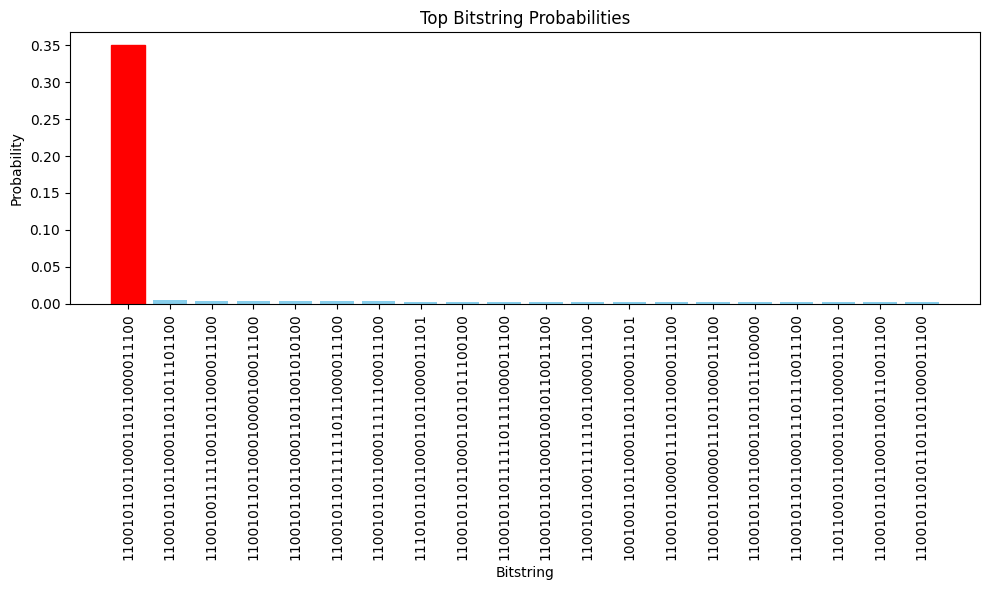

The peak bitstring for Problem 2 is: 1100101101100011011000011100


In [6]:
########## Quantum Circuit Solver - PROBLEM 2 Swift Rise - BlueQubit Hackathon 2025 by Jamie Kraus 04/12/2025 ##########

import bluequbit
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def solve_problem_2(api_key, qasm_file_path, plot_results=True):
    """
    Solves Problem 2 of the BlueQubit Hackathon by finding the peak bitstring
    in a 28-qubit circuit, and optionally plots the results.

    Args:
        api_key (str): Your BlueQubit API key.
        qasm_file_path (str): The path to the .qasm file.
        plot_results (bool, optional): Whether to plot the bitstring probabilities.
            Defaults to True.

    Returns:
        str: The peak bitstring (or None on error).
    """
    try:
        # Initialize BlueQubit with the provided API key
        bq = bluequbit.init(api_key)

        # Load the circuit from the .qasm file
        with open(qasm_file_path, 'r') as f:
            qasm_content = f.read()

        # Create a QuantumCircuit object from the .qasm file content
        circuit = QuantumCircuit.from_qasm_str(qasm_content)

        # Check the number of qubits
        num_qubits = circuit.num_qubits
        if num_qubits > 20:  # Statevector simulation is limited to a smaller number of qubits
            print(f"Circuit has {num_qubits} qubits.  Using sample_measurement.")
            result = bq.run(circuit, shots=8192) # increased shots
            counts = result.get_counts()

            # Convert counts to probabilities
            total_counts = sum(counts.values())
            probabilities = {bitstring: count / total_counts for bitstring, count in counts.items()}

             # Find the bitstring with the maximum probability
            peak_bitstring = max(probabilities, key=probabilities.get)
        else:
            # Simulate the circuit on BlueQubit
            result = bq.run(circuit)

            # Get the statevector from the result
            statevector = Statevector(result.get_statevector())

            # Get the probabilities for each bitstring
            probabilities = statevector.probabilities()

             # Get the binary strings
            bitstrings = [format(i, '0' + str(num_qubits) + 'b') for i in range(2**num_qubits)]
            probabilities = dict(zip(bitstrings, probabilities))

             # Find the bitstring with the maximum probability
            peak_bitstring = max(probabilities, key=probabilities.get)
        # Create a DataFrame for easy manipulation and visualization
        df = pd.DataFrame(list(probabilities.items()), columns=['Bitstring', 'Probability'])

        # Sort the DataFrame by probability in descending order
        df = df.sort_values(by='Probability', ascending=False)



        if plot_results:
            # Select the top N bitstrings for plotting
            N = min(20, len(df))  # Adjust this number based on how many bitstrings you want to visualize
            top_df = df.head(N)

            # Create the plot to visualize the bitstring probabilities
            plt.figure(figsize=(10, 6))
            bars = plt.bar(top_df['Bitstring'], top_df['Probability'], color='skyblue')
            plt.xticks(rotation=90)  # Rotate the bitstring labels on the x-axis for readability
            plt.xlabel('Bitstring')
            plt.ylabel('Probability')
            plt.title('Top Bitstring Probabilities')

            # Highlight the peak bitstring in red
            for bar, bitstring in zip(bars, top_df['Bitstring']):
                if bitstring == peak_bitstring:
                    bar.set_color('red')

            # Adjust layout for better fit and display the plot
            plt.tight_layout()
            plt.show()

        return peak_bitstring

    except Exception as e:
        print(f"An error occurred: {e}")
        return None

if __name__ == "__main__":
        # Replace with your actual API key and .qasm file path
        api_key = "YOUR_BLUEQUBIT_API_KEY"  # Replace with your BlueQubit API key
        qasm_file_path = "YOUR_DIRECTORY/P2_swift_rise.qasm"  # Updated to Problem 2's file path

        peak_bitstring = solve_problem_2(api_key, qasm_file_path, plot_results=True)

        if peak_bitstring:
                print(f"The peak bitstring for Problem 2 is: {peak_bitstring}")
        else:
                print("Failed to solve Problem 2.")


[BQ-PYTHON-SDK][WARNING] - Beta version 0.12.0b1 of BlueQubit Python SDK is being used.


Current working directory: C:\Users\Jamie\BlueQubit Hackathon\2025_Hackathon
Attempting to open file at: C:\Users\Jamie\BlueQubit Hackathon\2025_Hackathon\P3_sharp_peak.qasm
Circuit has 44 qubits. Using mps.cpu device.
[BQ-PYTHON-SDK][INFO] - Submitted: Job ID: U7uQbl8bdIyFApEb, device: mps.cpu, run status: RUNNING, created on: 2025-04-13 02:53:07 UTC, estimated runtime: 100 ms, estimated cost: $0.00, num qubits: 44


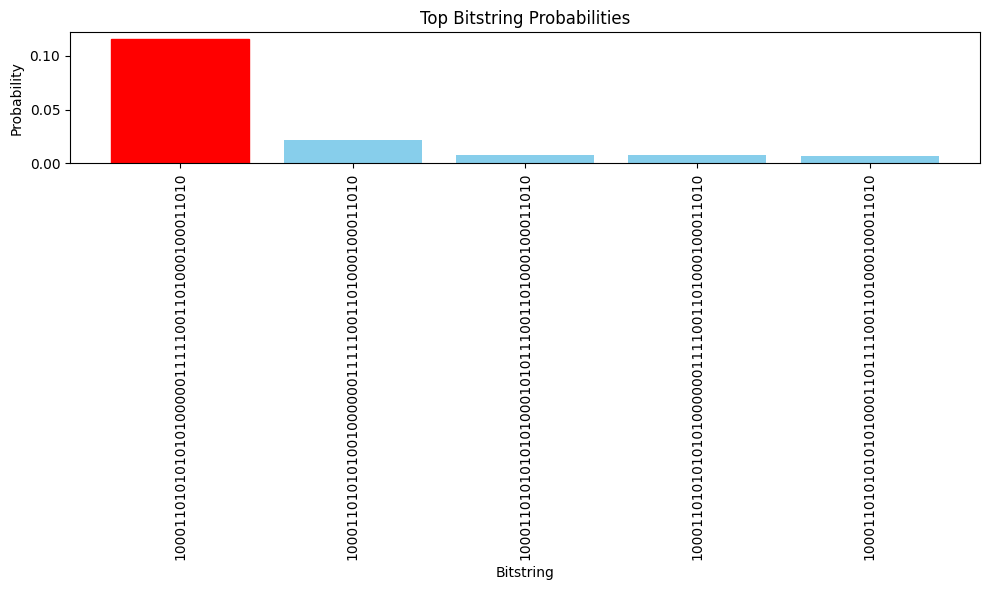

The peak bitstring for Problem 3 is: 10001101010101010000011111001101000100011010


In [3]:
########## Quantum Circuit Solver - PROBLEM 3 Sharp Peak - BlueQubit Hackathon 2025 by Jamie Kraus 04/12/2025 ##########

import bluequbit
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os  # Import the os module

def solve_problem_3(api_key, qasm_file_path, plot_results=True):
    """
    Solves Problem 3 of the BlueQubit Hackathon by finding the peak bitstring
    in a 44-qubit circuit, and optionally plots the results.

    Args:
        api_key (str): Your BlueQubit API key.
        qasm_file_path (str): The path to the .qasm file.
        plot_results (bool, optional): Whether to plot the bitstring probabilities.
        Defaults to True.

    Returns:
        str: The peak bitstring (or None on error).
    """
    try:
        # Initialize BlueQubit with the provided API key
        bq = bluequbit.init(api_key)  # Make absolutely sure api_key is correct

        # Print the current working directory
        cwd = os.getcwd()
        print(f"Current working directory: {cwd}")

        # Construct the absolute path
        absolute_path = os.path.join(cwd, qasm_file_path)
        print(f"Attempting to open file at: {absolute_path}")

        # Check if the file exists
        if not os.path.exists(absolute_path):
            raise FileNotFoundError(f"File not found at: {absolute_path}")

        # Load the circuit from the .qasm file
        with open(absolute_path, 'r') as f:
            qasm_content = f.read()

        # Create a QuantumCircuit object from the .qasm file content
        circuit = QuantumCircuit.from_qasm_str(qasm_content)

        # Check the number of qubits
        num_qubits = circuit.num_qubits
        if num_qubits > 34:
            device = 'mps.cpu'
            print(f"Circuit has {num_qubits} qubits. Using {device} device.")
            result = bq.run(circuit, shots=8192, device=device)
            counts = result.get_counts()
            if counts:
                # Convert counts to probabilities
                total_counts = sum(counts.values())
                probabilities = {bitstring: count / total_counts for bitstring, count in counts.items()}
                # Find the bitstring with the maximum probability
                peak_bitstring = max(probabilities, key=probabilities.get)
            else:
                raise ValueError("No counts returned from sampling.")
        else:
            # Simulate the circuit on BlueQubit
            result = bq.run(circuit, device='mps.cpu')

            # Get the statevector from the result
            statevector = Statevector(result.get_statevector())

            # Get the probabilities for each bitstring
            probabilities = statevector.probabilities()

            # Get the binary strings
            bitstrings = [format(i, '0' + str(num_qubits) + 'b') for i in range(2**num_qubits)]
            probabilities = dict(zip(bitstrings, probabilities))

            # Find the bitstring with the maximum probability
            peak_bitstring = max(probabilities, key=probabilities.get)

        # Create a DataFrame for easy manipulation and visualization
        df = pd.DataFrame(list(probabilities.items()), columns=['Bitstring', 'Probability'])

        # Sort the DataFrame by probability in descending order
        df = df.sort_values(by='Probability', ascending=False)

        if plot_results:
            # Select the top N bitstrings for plotting
            N = min(5, len(df))
            top_df = df.head(N)

            # Create the plot to visualize the bitstring probabilities
            plt.figure(figsize=(10, 6))
            bars = plt.bar(top_df['Bitstring'], top_df['Probability'], color='skyblue')
            plt.xticks(rotation=90)
            plt.xlabel('Bitstring')
            plt.ylabel('Probability')
            plt.title('Top Bitstring Probabilities')

            # Highlight the peak bitstring in red
            for bar, bitstring in zip(bars, top_df['Bitstring']):
                if bitstring == peak_bitstring:
                    bar.set_color('red')

            # Adjust layout for better fit and display the plot
            plt.tight_layout()
            plt.show()

        return peak_bitstring, df  # Return the peak bitstring and the dataframe

    except Exception as e:
        print(f"An error occurred: {e}")
        return None, None

if __name__ == "__main__":
    # Replace with your actual API key and .qasm file path
    api_key = "YOUR_BLUEQUBIT_API_KEY"  # <---- PASTE YOUR API KEY HERE, INSIDE THE QUOTES!
    qasm_file_path = "YOUR_DIRECTORY/P3_sharp_peak.qasm"

    peak_bitstring, probability_df = solve_problem_3(api_key, qasm_file_path, plot_results=True)

    if peak_bitstring:
        print(f"The peak bitstring for Problem 3 is: {peak_bitstring}")
        # you can now access the dataframe here as probability_df
    else:
        print("Failed to solve Problem 3.")

[BQ-PYTHON-SDK][WARNING] - Beta version 0.12.0b1 of BlueQubit Python SDK is being used.


[BQ-PYTHON-SDK][INFO] - Submitted: Job ID: 1XFqjJ7f04Fp3EI7, device: mps.cpu, run status: RUNNING, created on: 2025-04-13 15:44:00 UTC, estimated runtime: 100 ms, estimated cost: $0.00, num qubits: 8
[BQ-PYTHON-SDK][INFO] - Submitted: Job ID: 2ifLaimycyZ3ocw0, device: mps.cpu, run status: RUNNING, created on: 2025-04-13 15:45:44 UTC, estimated runtime: 100 ms, estimated cost: $0.00, num qubits: 8
[BQ-PYTHON-SDK][INFO] - Submitted: Job ID: x4St8NJxsQF3piXK, device: mps.cpu, run status: RUNNING, created on: 2025-04-13 15:47:28 UTC, estimated runtime: 100 ms, estimated cost: $0.00, num qubits: 8
[BQ-PYTHON-SDK][INFO] - Submitted: Job ID: xB3XZW63cfq4gyI2, device: mps.cpu, run status: RUNNING, created on: 2025-04-13 15:49:13 UTC, estimated runtime: 100 ms, estimated cost: $0.00, num qubits: 8
[BQ-PYTHON-SDK][INFO] - Submitted: Job ID: yfO8HZNxiWU2bYdF, device: mps.cpu, run status: PENDING, created on: 2025-04-13 15:50:58 UTC, estimated runtime: 100 ms, estimated cost: $0.00, num qubits: 8


[BQ-PYTHON-SDK][WARNING] - Retrying. Num retries 1. ConnectTimeout: HTTPSConnectionPool(host='app.bluequbit.io', port=443): Max retries exceeded with url: /api/v1/jobs?limit=100&job_ids=yfO8HZNxiWU2bYdF&need_qc_unprocessed=False&need_top_100k=False (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x000002BC55989510>, 'Connection to app.bluequbit.io timed out. (connect timeout=15.0)'))


[BQ-PYTHON-SDK][INFO] - Submitted: Job ID: TD7sWSbFpmp7W2Oi, device: mps.cpu, run status: RUNNING, created on: 2025-04-13 15:53:50 UTC, estimated runtime: 100 ms, estimated cost: $0.00, num qubits: 8
Final bitstring for Problem 4: 100111101010110110110111110010100111011010000111


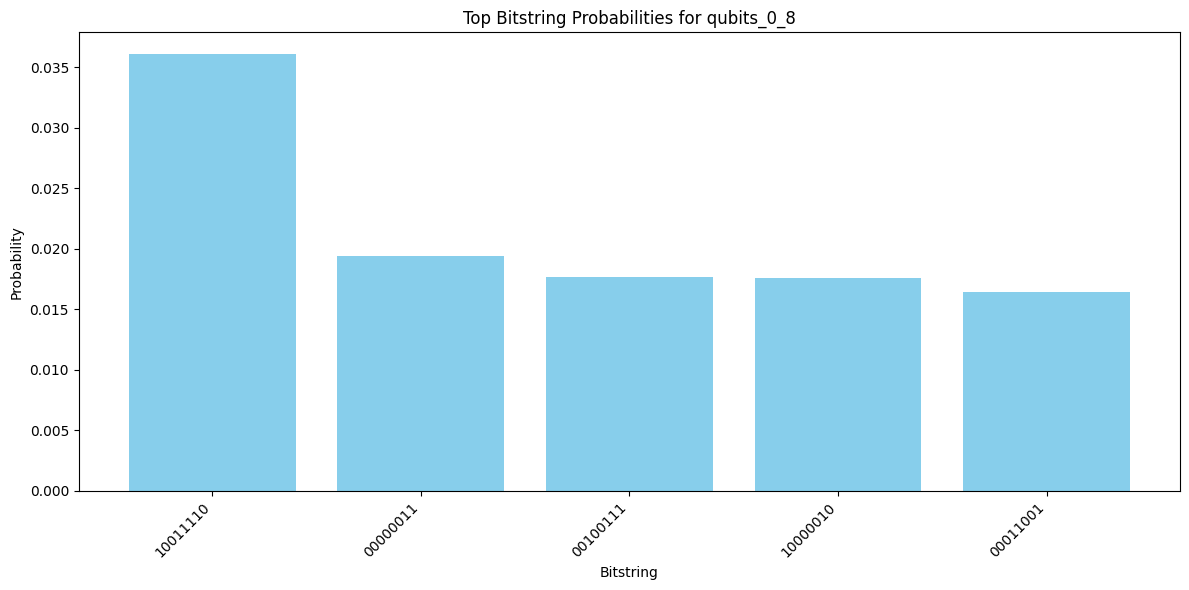

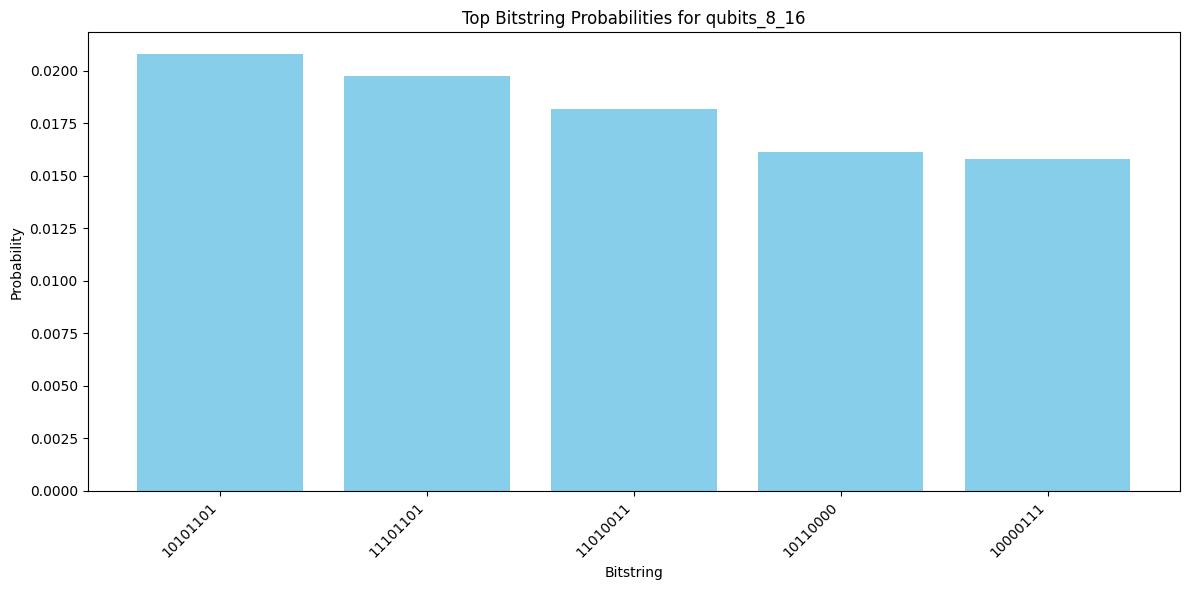

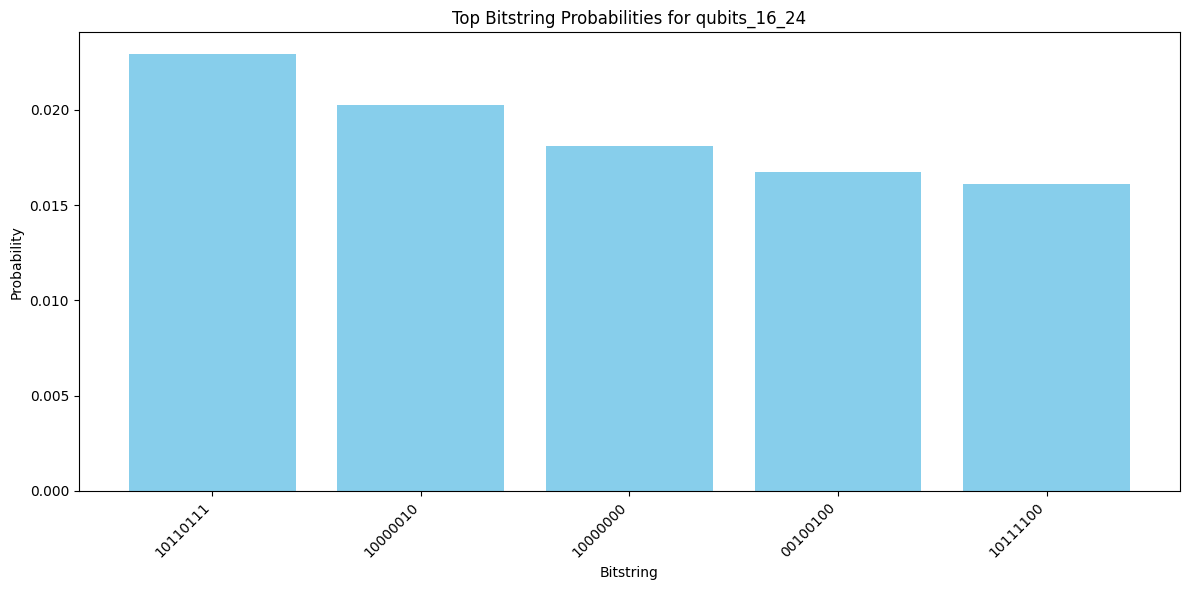

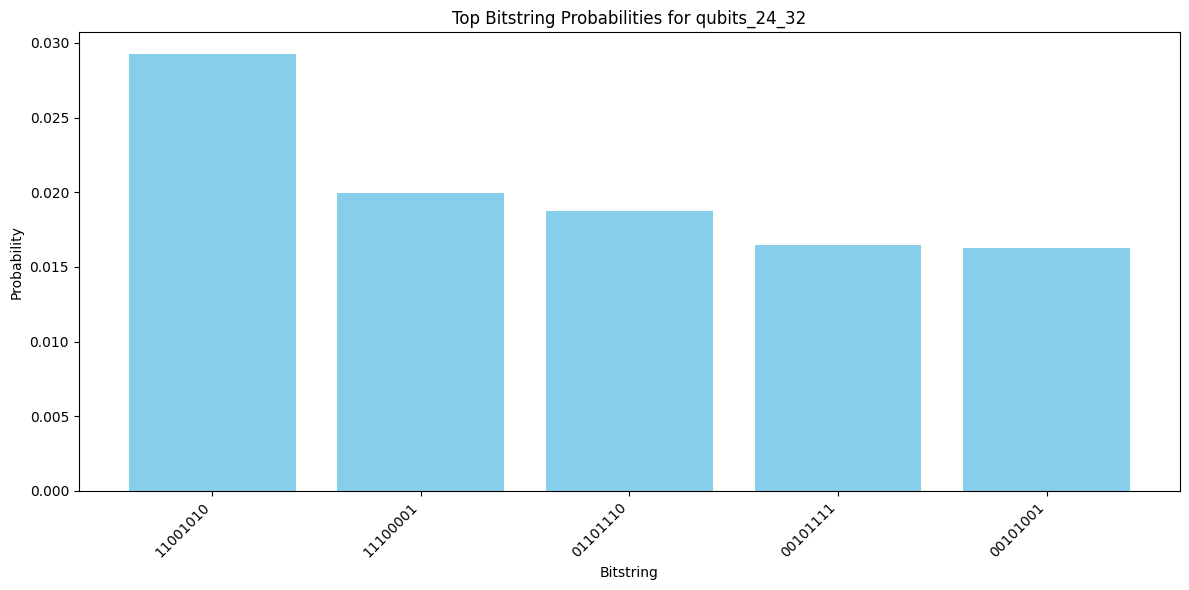

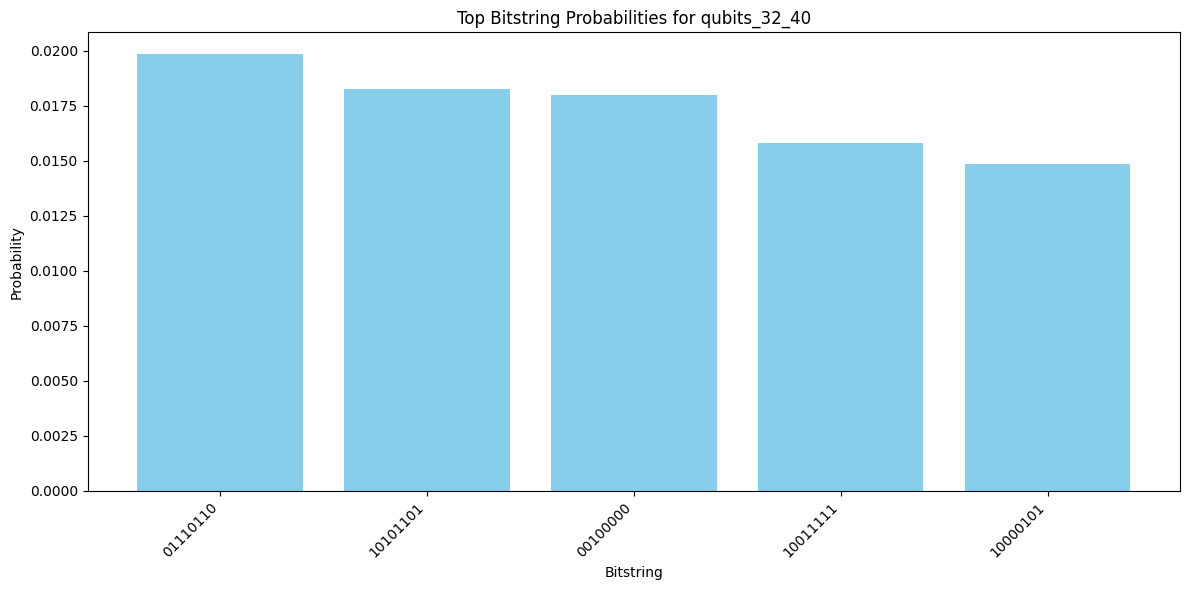

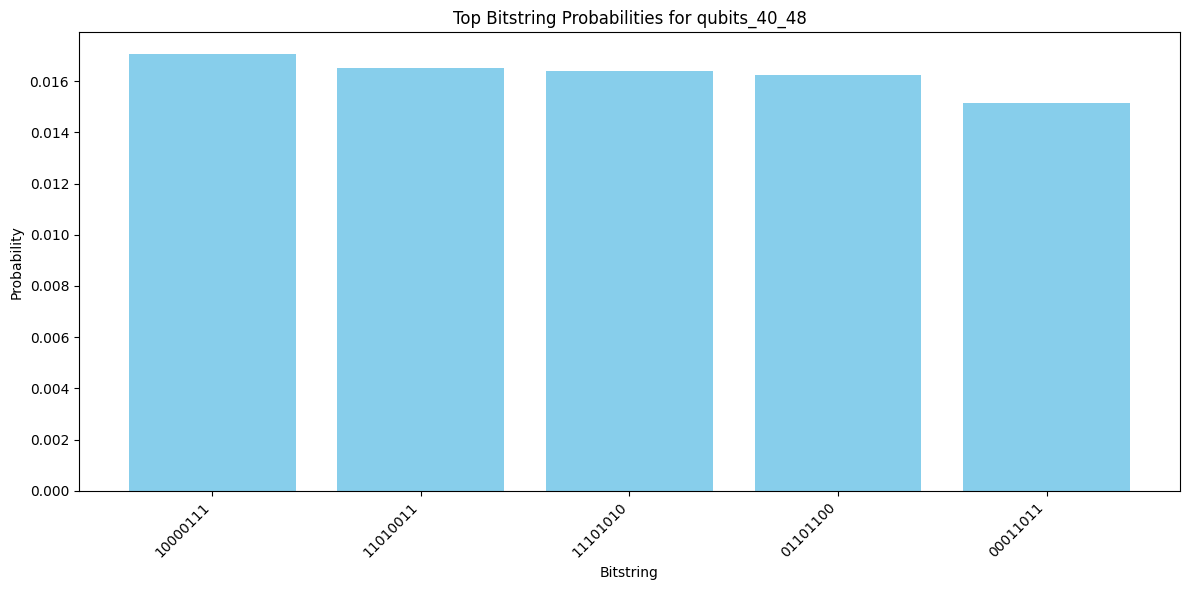

In [36]:
########## Quantum Circuit Solver - PROBLEM 4 Golden Mountain - BlueQubit Hackathon 2025 by Jamie Kraus 04/12/2025 ##########

import bluequbit
from qiskit import QuantumCircuit, transpile
import os
import pandas as pd
import matplotlib.pyplot as plt

def solve_problem_4_layer_qubit(api_key, qasm_file_path, num_qubits=8, max_two_qubit_gates=800):
    try:
        bq = bluequbit.init(api_key)
        cwd = os.getcwd()
        absolute_path = os.path.join(cwd, qasm_file_path)
        if not os.path.exists(absolute_path):
            raise FileNotFoundError(f"File not found at: {absolute_path}")
        with open(absolute_path, 'r') as f:
            qasm_content = f.read()
        circuit = QuantumCircuit.from_qasm_str(qasm_content)
        optimized_circuit = transpile(circuit, optimization_level=1)

        final_bitstring = ""
        all_probabilities = {}

        for start_qubit in range(0, 48, num_qubits):
            qubit_range = list(range(start_qubit, min(start_qubit + num_qubits, 48)))
            sub_circuit = QuantumCircuit(len(qubit_range))
            two_qubit_gate_count = 0
            layer_count = 0
            for instruction in optimized_circuit.data:
                gate = instruction.operation
                qubits = instruction.qubits
                qubit_indices = [q._index for q in qubits]
                if all(q in range(48) and q in qubit_range for q in qubit_indices):
                    new_qubits = [qubit_range.index(q) for q in qubit_indices]
                    if len(qubits) == 2:
                        two_qubit_gate_count += 1
                        if two_qubit_gate_count > max_two_qubit_gates:
                            break
                    sub_circuit.append(gate, new_qubits)
                    layer_count += 1
            if sub_circuit.num_qubits > 0:
                result = bq.run(sub_circuit, shots=40000, device='mps.cpu')
                counts = result.get_counts()
                if counts:
                    total_counts = sum(counts.values())
                    probabilities = {bitstring: count / total_counts for bitstring, count in counts.items()}
                    peak_bitstring = max(probabilities, key=probabilities.get)
                    final_bitstring += peak_bitstring
                    all_probabilities[f"qubits_{start_qubit}_{start_qubit+num_qubits}"] = probabilities
                else:
                    raise ValueError(f"No counts returned for qubits {qubit_range}.")
            else:
                final_bitstring += "0" * len(qubit_range)

        return final_bitstring, all_probabilities

    except Exception as e:
        print(f"An error occurred: {e}")
        return None, None

def plot_subcircuit_probabilities(probabilities_dict):
    """Plots probabilities for each sub-circuit."""
    for subcircuit, probabilities in probabilities_dict.items():
        df = pd.DataFrame(list(probabilities.items()), columns=['Bitstring', 'Probability'])
        df = df.sort_values(by='Probability', ascending=False).head(5)  # Top 5

        plt.figure(figsize=(12, 6))
        bars = plt.bar(df['Bitstring'], df['Probability'], color='skyblue')
        plt.xticks(rotation=45, ha='right')
        plt.xlabel('Bitstring')
        plt.ylabel('Probability')
        plt.title(f'Top Bitstring Probabilities for {subcircuit}')
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    api_key = "YOUR_BLUEQUBIT_API_KEY"
    qasm_file_path = "YOUR_DIRECTORY/P4_golden_mountain.qasm"

    final_bitstring, all_probabilities = solve_problem_4_layer_qubit(api_key, qasm_file_path)

    if final_bitstring:
        print(f"Final bitstring for Problem 4: {final_bitstring}")
        plot_subcircuit_probabilities(all_probabilities)
    else:
        print("Failed to solve Problem 4.")